In [2]:
# os 환경 변수 GEMINI API KEY 입력
import os
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
from langgraph.graph import StateGraph, START, END

/Users/dohyunkim/Documents/langchain-study/langgraph/.venv/lib/python3.13/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


[Workflow 공식문서](https://docs.langchain.com/oss/python/langgraph/workflows-agents#orchestrator-worker)

# Orchestrator-Worker

## Model 정의

In [5]:
from langchain.chat_models import init_chat_model
from typing import TypedDict
from pydantic import BaseModel, Field



model = init_chat_model("gpt-5-nano")

## State 정의

In [10]:
from typing import List

# 1. 데이터 모델 정의 (Plan & Section)
# 팀장(Orchestrator)이 짤 계획표의 양식
class Section(BaseModel):
    name: str = Field(description='목차의 제목')
    description: str = Field(description='이 섹션에서 다뤄야 할 핵심 내용')


In [12]:
import operator
from typing import Annotated

# 2. State 정의 (Reducer 필수!)
class ReportState(TypedDict):
    topic: str
    sections: List[Section]
    completed_sections: Annotated[List[str], operator.add]
    final_report: str


In [13]:
# Worker에게 전달할 별도의 State (작업 지시서)
class WorkerState(TypedDict):
    section: Section

In [14]:
class Plan(BaseModel):
    sections: List[Section] = Field(description="보고서 작성을 위한 목차 리스트")

In [15]:
planner_llm = model.with_structured_output(Plan)

## Node 정의

In [25]:
# [Orchestrator] 팀장 노드: 계획 수립
def orchestrator_node(state: ReportState):
    topic = state["topic"]
    print(f"\n--- [Orchestrator] '{topic}' 보고서 계획 수립 중 ---")

    # 보고서 목차를 생성 (최대 3개로 제한하여 속도 조절)
    plan = planner_llm.invoke(f"'{topic}'에 대한 보고서 목차를 짜줘. 3개 섹션 이내로 구성해.")

    print(f"생성된 계획: {[s.name for s in plan.sections]}")
    return {"sections": plan.sections}

In [26]:
# [Worker] 팀원 노드: 섹션 집필
# 이 노드는 여러 개가 복제되어 동시에 실행
def worker_node(state: WorkerState):
    section = state["section"]
    print(f"   --- [Worker] 집필 중: {section.name} ---")

    prompt = f"""
    다음 섹션에 대한 내용을 짧게 작성해줘.
    제목: {section.name}
    내용 가이드: {section.description}
    """

    response = model.invoke(prompt)
    content = f"## {section.name} \n {response.content}"
    return {'completed_sections': [content]}


In [27]:
# [Synthesizer] 편집자 노드: 취합
def synthesizer_node(state: ReportState):
    print("\n--- [Synthesizer] 모든 원고 취합 및 최종 편집 ---")

    # 리스트에 모인 조각글들을 하나로 합침
    completed = state["completed_sections"]
    final_report = "\n".join(completed)

    return {"final_report": final_report}

## 그래프 생성

### [Send API](https://reference.langchain.com/python/langgraph/types/?h=send#langgraph.types.Send)

In [28]:
from langgraph.types import Send

# 5. 동적 라우팅 로직 (Map: 1 -> N)
# 일반적인 edge가 아니라, 리스트 개수만큼 노드를 생성해서 뿌려주는 역할
def assign_workers(state: ReportState):
    sections = state['sections']
    
    return [Send('worker_node', {'section': section}) for section in sections]


In [31]:
# 6. 그래프 조립
workflow = StateGraph(ReportState)

workflow.add_node('orchestrator_node', orchestrator_node)
workflow.add_node('worker_node', worker_node)
workflow.add_node('synthesizer_node', synthesizer_node)

# 6-1. 시작 -> 팀장
workflow.add_edge(START, 'orchestrator_node')

# 6-2. 팀장 -> (Map) -> 팀원들 (Conditional Edge)
workflow.add_conditional_edges(
    'orchestrator_node',
    assign_workers,
    ['worker_node']
)

# 6-3. 팀원들 -> (Reduce) -> 편집자
workflow.add_edge('worker_node', 'synthesizer_node')



# 6-4. 편집자 -> 종료
workflow.add_edge('synthesizer_node', END)


In [32]:
app = workflow.compile()

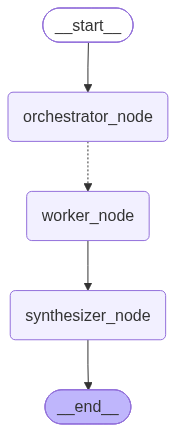

In [33]:
app

## 실행

In [34]:
inputs = {"topic": "생성형 AI의 미래"}
result = app.invoke(inputs)


--- [Orchestrator] '생성형 AI의 미래' 보고서 계획 수립 중 ---
생성된 계획: ['섹션 1. 생성형 AI의 현황과 핵심 기술', '섹션 2. 사회경제적 영향과 정책·윤리', '섹션 3. 미래 전망과 전략']
   --- [Worker] 집필 중: 섹션 1. 생성형 AI의 현황과 핵심 기술 ---
   --- [Worker] 집필 중: 섹션 2. 사회경제적 영향과 정책·윤리 ---
   --- [Worker] 집필 중: 섹션 3. 미래 전망과 전략 ---

--- [Synthesizer] 모든 원고 취합 및 최종 편집 ---


In [35]:
result["final_report"]

'## 섹션 1. 생성형 AI의 현황과 핵심 기술 \n 섹션 1. 생성형 AI의 현황과 핵심 기술\n\n- 현황 요약: 최근 대형 언어모델과 확산모델의 상용화가 가속화되며, 다중 태스크와 멀티모달 기능이 표준으로 자리잡고 있다. API/서비스 중심의 생태계 확장과 함께 규제 및 안전 이슈도 함께 대두되고 있다.\n\n- 핵심 기술 및 작동 원리: 트랜스포머 기반 대형 언어모델(LLM), 확산 모델, 변형형(VAE) 등 다양한 생성 기술이 발전. Retrieval-Augmented Generation(RAG), 멀티모달 모델, 강화학습을 통한 정책 정렬(RLHF) 등도 중요하다. 작동 원리는 사전학습-미세조정-보상학습의 파이프라인으로, 프롬프트 설계 및 디코딩 전략으로 텍스트/이미지/코드 등을 생성한다.\n\n- 데이터 관리: 데이터 수집의 라이선스/저작권 준수, 품질 관리와 편향 완화, 데이터 거버넌스와 프라이버시 보호, 합성 데이터의 활용 및 데이터 버전 관리가 핵심이다.\n\n- 평가 방법: 자동 지표와 인간 평가의 혼합, 벤치마크 기반 평가와 실사용 시나리오 평가, 안전성·공정성 평가, 재현성과 견고성 검증을 포함한 실험 설계가 필요하다.\n\n- 도전 과제와 전망: 비용 및 에너지 소모 최소화, 데이터 편향 개선, 안전성 강화, 해석 가능성 향상, 사용자 맞춤형 적용 확대가 앞으로의 핵심 방향이다.\n## 섹션 2. 사회경제적 영향과 정책·윤리 \n 섹션 2. 사회경제적 영향과 정책·윤리\n\n- 노동시장 변화: 생성형 AI의 도입으로 일부 직무가 재편되거나 축소되고, 새로운 직무가 생겨나며 재교육과 평생학습의 중요성이 커진다.\n- 산업생태계 재편: 데이터·AI 서비스 중심의 가치사슬이 확산되고, 플랫폼 간 협력·경계가 모호해지며 중소기업과 대기업 간 협력 모델이 다양해진다.\n- 프라이버시·보안 이슈: 데이터 수집·활용 및 모델 학습 과정에서 프라이버시 침해 위험과 모델 추론 공격 등 보안 이슈가 제기될 수 있다.\n- 데이터 소유권: 데이터의 소유

### develop (화학적 결합)

In [36]:
# [Synthesizer] 편집자 노드: 단순 취합이 아니라 '화학적 결합'을 수행
def synthesizer_node(state: ReportState):
    topic = state["topic"]
    completed_docs = state["completed_sections"]

    print(f"\n--- [Synthesizer] 원고 {len(completed_docs)}건 도착. 최종 편집 시작 ---")

    # 1. 일단 텍스트 덩어리로 병합

    raw_content = "\n\n".join(completed_docs)


    # 2. LLM에게 '전문 편집자' 역할 부여
    prompt = f"""
    당신은 전문 리포트 편집자입니다.
    다음은 '{topic}'에 대해 여러 작가가 나누어 쓴 원고들입니다.

    이 초안들을 바탕으로 **하나의 자연스럽고 전문적인 보고서**로 다시 작성해주세요.

    [지시사항]
    1. 각 섹션의 연결이 매끄러워야 합니다.
    2. 전체를 아우르는 '서론'과 '결론'을 추가해주세요.
    3. 마크다운(Markdown) 형식을 사용하여 가독성을 높여주세요.

    [원고 내용]
    {raw_content}
    """

    # 최종 생성을 위한 LLM 호출
    message = model.invoke(prompt)
    
    return {'final_report': message.content}



In [37]:
# 6. 그래프 조립
workflow = StateGraph(ReportState)

workflow.add_node("orchestrator_node", orchestrator_node)
workflow.add_node("worker_node", worker_node)
workflow.add_node("synthesizer_node", synthesizer_node)

# 1. 시작 -> 팀장
workflow.add_edge(START, "orchestrator_node")

# 2. 팀장 -> (Map) -> 팀원들 (Conditional Edge)
workflow.add_conditional_edges(
    "orchestrator_node",
    assign_workers,
    ["worker_node"] # 이 부분은 생략 가능하지만 명시적으로 적어줌
)

# 3. 팀원들 -> (Reduce) -> 편집자
workflow.add_edge("worker_node", "synthesizer_node")

# 4. 편집자 -> 종료
workflow.add_edge("synthesizer_node", END)

In [38]:
app = workflow.compile()

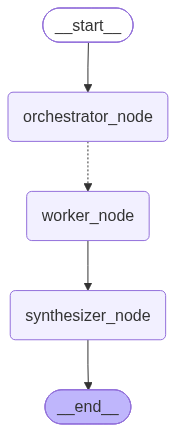

In [39]:
app

In [40]:
inputs = {"topic": "생성형 AI의 미래"}
result = app.invoke(inputs)


--- [Orchestrator] '생성형 AI의 미래' 보고서 계획 수립 중 ---
생성된 계획: ['1. 기술 진화와 생태계', '2. 사회경제적 영향과 도전', '3. 미래 전망과 전략적 시사점']
   --- [Worker] 집필 중: 1. 기술 진화와 생태계 ---
   --- [Worker] 집필 중: 2. 사회경제적 영향과 도전 ---
   --- [Worker] 집필 중: 3. 미래 전망과 전략적 시사점 ---

--- [Synthesizer] 원고 3건 도착. 최종 편집 시작 ---


In [41]:
result["final_report"]

'# 생성형 AI의 미래: 기술 진화, 사회경제적 영향, 그리고 전략적 시사점\n\n본 보고서는 생성형 AI를 둘러싼 기술 진화와 생태계의 변화가 사회경제 구조와 정책, 기업 전략에 어떤 함의를 주는지 종합적으로 조망합니다. 각 섹션은 서로 연결되어 있으며, 마지막에 제시하는 전략적 시사점은 앞선 분석의 핵심 요점을 반영합니다.\n\n---\n\n## 서론\n\n생성형 AI의 속도감 있는 발전은 거대 foundation 모델의 확장, 멀티모달 입력 처리의 보편화, 지시 학습 중심의 RLHF 개선, 그리고 지식 증류 등 기술적 축의 혁신을 촉진하고 있습니다. 동시에 프롬프트 엔지니어링과 파인튜닝의 보편화로 맞춤화와 데이터 효율성이 크게 향상되었으며, 안전성과 거버넌스 체계의 강화가 정책·규제 환경의 핵심 축으로 부상하고 있습니다. 이러한 기술·인프라·표준화의 변화가 서로 얽히며 생태계를 구성하고, 이는 사회경제적 구조와 기업 전략에 직결되는 다층적 파급효과를 만들어내고 있습니다. 본 보고서는 이 흐름을 기술 진화의 생태계 관점에서 정리하고, 그에 따른 사회경제적 도전과 대응 전략을 제시합니다.\n\n---\n\n## 1. 기술 진화와 생태계\n\n- 핵심 기술 동향\n  - 거대 foundation 모델의 발전, 멀티모달/다중 입력 처리, 지시 학습(RLHF 중심) 및 지식 증류\n  - 프롬프트 엔지니어링과 파인튜닝으로의 맞춤화 및 데이터 효율성 향상\n  - 안전성·거버넌스 강화: 편향 완화, 프라이버시 보호, 규제 준수\n\n- 인프라 동향\n  - 클라우드-엣지 하이브리드 구도 및 GPU/TPU 등 AI 가속기 인프라의 확산\n  - 데이터 파이프라인, 피처 스토어, MLOps를 통한 재현성과 운영 자동화\n  - 연합학습·차등 프라이버시 등 프라이버시 보호 기술과 모델 경량화\n\n- 표준화와 협력 체계\n  - 국제 표준/가이드: ISO/IEC AI 표준, NIST AI RMF, IEEE 윤리 가이드\n  - 포맷·호환성: ONNX 등 모델 포맷과 상